In [25]:
import math
import pandas as pd
import numpy as np
import json

# READ & CLEAN DATA

- drop testing workerids
- remove duplicates (item getting recorded multiple times by Multitude for some reason)

In [2]:
df = pd.read_csv("./dataRaw/experiment_6323_results.csv")

unnecessary_cols = ["questionid", "filename", "listnumber", "assignmentid", "hitid", "origin", "timestamp", "partid", "id", "imgorder"]
unformatted_df = df.drop(unnecessary_cols, axis=1)

testworkers = ["test", "123", "testFirefox", "testRedirect", "testFinal"]  # add more to this list if there were more test runs
unformatted_df = unformatted_df[~unformatted_df["workerid"].isin(testworkers)]

len(unformatted_df["workerid"].unique())

78

## FORMAT RATING VALUES FROM THE ANSWER COLUMN

In [3]:
def format_answer(answer, weak_word, strong_word, antonym):
    """
    returns multiple results.
    whatever data is needed out of the answer, edit and manipulate it in this function
    """
    results = json.loads(json.loads(answer))
    new_dict = dict()
    
    if not results.get("ratings"):
        return None, None, None, None, None
    for item in results["ratings"]:
        name = item["image"].replace(".png", "")
        new_dict.update(
            {name: item["rating"]}
        )

    if results["speaker"] in ["frank", "bri"]:
        speakerType = "native"
    else:
        speakerType = "nonnative"
    
    if results["speaker"] in ["bri", "sasha"]:
        speakerGender = "female"
    else:
        speakerGender = "male"

    # weak word rating, strong word rating, antonym rating
    return new_dict.get(weak_word), new_dict.get(strong_word), new_dict.get(antonym), speakerType, speakerGender

In [4]:
answers_only_df = unformatted_df.apply(
    lambda x: format_answer(x.answer, x.weak, x.strong, x.antonym), 
    axis=1, 
    result_type="expand",  # this is how you make it into multiple columns
)
answers_only_df.columns=["derivationStrength", "strongRating", "antonymRating", "speakerType", "speakerGender"]
answers_only_df

,derivationStrength,strongRating,antonymRating,speakerType,speakerGender
1,90.0,10.0,0.0,nonnative,male
2,35.0,60.0,5.0,native,female
3,94.0,6.0,0.0,nonnative,male
4,100.0,0.0,0.0,nonnative,male
5,100.0,0.0,0.0,native,female
...,...,...,...,...,...
2712,100.0,0.0,0.0,nonnative,female
2713,100.0,0.0,0.0,native,female
2714,100.0,0.0,0.0,nonnative,female
2715,100.0,0.0,0.0,native,male


## READ WORD FREQ DICT IN

In [5]:
word_freq_dict_df = pd.read_csv("./dataRaw/wordFreqDict.csv")
word_freq_dict_df.head()

word_freq_dict_df[word_freq_dict_df['Frequency'].isin(["x"])]

,Word,Rank,Frequency


## RENAME COLUMN NAMES TO WHAT THE MODEL NEEDS

In [6]:
answers_df = pd.concat([unformatted_df, answers_only_df], axis=1)
answers_df = answers_df.drop(["answer"], axis=1)

answers_df = answers_df.rename(columns={
    "workerid": "participantId",
    "itemid": "itemId",
    "type": "itemType"
})

answers_df[answers_df["participantId"] == "66b153e252bf568e5c9f0ba2"]

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,antonymRating,speakerType,speakerGender


# FILTER - EXCLUSION CRITERIA

### Picture Rating Control Trials

In [7]:
# filter out rating scores
#    - if avg. rating across all unambiguous trials were < 80%
umambiguous_trials = answers_df[answers_df["itemType"] == "unambiguous"]
picrating_filtered_participants = list(
    pd.unique(
        umambiguous_trials.groupby("participantId").filter(
            lambda x: x["derivationStrength"].mean() < 80
        )["participantId"]
    )
)
picrating_filtered_participants

[]

In [8]:
# looking to see if there are any outliers
critical_trials = answers_df[answers_df["itemType"] != "unambiguous"]

outliers = critical_trials.groupby("participantId").filter(
    # lambda x: x["derivationStrength"].mean() < avg_crit_derivationstrength
    lambda x: x["derivationStrength"].mean() < 15
)["participantId"]

ratingoutlier_participants = list(outliers.unique())
ratingoutlier_participants

['6978d830c5d415696508430d',
 '69d5632f4815bcc4cb7242bf',
 '6a0a0fd9f370053c3505dc0f',
 '6a1de36b3f5c6160ff6bf6a4',
 '6a2482e9af72b55296872b0d']

### Picture Rating Technical Problems

In [9]:
# a lot of responses for one person didn't get recorded unfortunately
countNaN = umambiguous_trials["derivationStrength"].isnull().groupby(
    umambiguous_trials["participantId"]
).sum().astype(int).reset_index(name="countNaN")

technical_prob_filtered_participants = list(countNaN[countNaN["countNaN"] > 1]["participantId"].unique())
technical_prob_filtered_participants

['69cc1fac2b52b1c4dd21cc7d']

## ToM Filtered Participants

Get a list from the R script:
- technical problems (anything over 10% of responses missing)
- control accuracy < 80%

In [10]:
nathan4u_filtered_participants = [
    # technical issues: 50+ unanswered
    "69c093d33989aa791c4e8b2d", 
    "6a2482e9af72b55296872b0d",
    "6a00dbcc626a780a8e5c07a4",
    "6a232745f21e165e2b54ed58",

    # control accuracy < 80%
    "6965bd850ce22095dd7a84ca",
    "6978d830c5d415696508430d",
    "69a6eb2bc679065ed1cecc51",
    "69ba37faee13f176e7635323",
    "69c093d33989aa791c4e8b2d",
    "69cc1fac2b52b1c4dd21cc7d",
    "69f674db81cb46678aae6391",
    "69fb86296fb6f0919bf31075",
    "6a00dbcc626a780a8e5c07a4",
    "6a14434573bcee3f17b7f762",
    "6a14e67cf20909f60e34ae64",
    "6a232745f21e165e2b54ed58",
    "6a2482e9af72b55296872b0d",
]

## Audio Filtered Participants

After transcribing the audio for the two practice perspective taking trials, any that did not choose the target word will be excluded.

Anyone who did not provide a response that is indicative of understanding the task in the final critical audio explanation will be excluded.

In [146]:
audio_filtered_participants = [
    # Missed any of the perspective taking trials (from the already filtered participants)
    "69f7b962446b32b08d58a1df",
    "69e816058da70eddb5dbc3e1",
    "69f6484996726366cacd162c",
    "69efe0b03221edd72686c185",
    "69ed15278090fe4438301d5c",
    "6a0a0fd9f370053c3505dc0f",
    "66da162f5538535e93490441",
    "69d5632f4815bcc4cb7242bf",
    "69cec122e3cb56c2e7000c6b",
    "6a012d3c523e7311f4e55f61",
    "69a0734d1d433d3694c8438f",
    "69e957ad6c65e153a1c65ae2"
]

## Total Filtered Participants

In [174]:
all_filtered_participants = list(set(
    picrating_filtered_participants + 
    # ratingoutlier_participants +
    nathan4u_filtered_participants + 
    audio_filtered_participants + 
    technical_prob_filtered_participants
))

print("total number of filtered participants: ", len(all_filtered_participants))
all_filtered_participants

total number of filtered participants:  25


['69f7b962446b32b08d58a1df',
 '6a232745f21e165e2b54ed58',
 '6a14e67cf20909f60e34ae64',
 '69cec122e3cb56c2e7000c6b',
 '69f6484996726366cacd162c',
 '69d5632f4815bcc4cb7242bf',
 '66da162f5538535e93490441',
 '69f674db81cb46678aae6391',
 '69e957ad6c65e153a1c65ae2',
 '69ed15278090fe4438301d5c',
 '69a0734d1d433d3694c8438f',
 '6a0a0fd9f370053c3505dc0f',
 '6a00dbcc626a780a8e5c07a4',
 '69fb86296fb6f0919bf31075',
 '69ba37faee13f176e7635323',
 '69a6eb2bc679065ed1cecc51',
 '69e816058da70eddb5dbc3e1',
 '69efe0b03221edd72686c185',
 '6a2482e9af72b55296872b0d',
 '69cc1fac2b52b1c4dd21cc7d',
 '6a14434573bcee3f17b7f762',
 '6978d830c5d415696508430d',
 '69c093d33989aa791c4e8b2d',
 '6965bd850ce22095dd7a84ca',
 '6a012d3c523e7311f4e55f61']

In [148]:
answers_df = answers_df[~answers_df["participantId"].isin(all_filtered_participants)]

# MERGE DFs TOGETHER

## all the word information back into the response dataframe

In [150]:
# get the weak word info
final_df = answers_df.merge(word_freq_dict_df, left_on="weak", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "weakRank",
    "Frequency": "weakFreq",
})

# get the strong word info
final_df = final_df.merge(word_freq_dict_df, left_on="strong", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "strongRank",
    "Frequency": "strongFreq",
})

# get the antonym word info
final_df = final_df.merge(word_freq_dict_df, left_on="antonym", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "antonymRank",
    "Frequency": "antonymFreq",
})

# create freq ratios
cols = ["weakFreq", "strongFreq", "antonymFreq", "weakRank", "strongRank", "antonymRank"]
final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce', axis=1)
final_df["freqRatio"] = final_df["weakFreq"] / final_df["strongFreq"]
# if freq ratio is nan, fill it with 2
final_df["freqRatio"] = final_df["freqRatio"].apply(lambda x: math.log10(x)).fillna(2, downcast='infer')
final_df.head(6)

/tmp/ipykernel_906222/2728389408.py:30: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric results.
  final_df["freqRatio"] = final_df["freqRatio"].apply(lambda x: math.log10(x)).fillna(2, downcast='infer')


,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,antonymRating,speakerType,speakerGender,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio
0,62c5f85ccf34c8d9c0650f6e,1,critical,soft,mushy,crunchy,panicked,introspective,90.0,10.0,0.0,nonnative,male,1381,27970,18362,478,14284,834,1.767265
1,661c09a749790db73f8faba5,1,critical,soft,mushy,crunchy,panicked,introspective,35.0,60.0,5.0,native,female,1381,27970,18362,478,14284,834,1.767265
2,66315563a848526fcfa7555b,1,critical,soft,mushy,crunchy,panicked,introspective,94.0,6.0,0.0,nonnative,male,1381,27970,18362,478,14284,834,1.767265
3,66577b950cf252021eff76f8,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,0.0,nonnative,male,1381,27970,18362,478,14284,834,1.767265
4,676956116c1a3416bf7b2afe,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,0.0,native,female,1381,27970,18362,478,14284,834,1.767265
5,695ea002344d7ca1605c747a,1,critical,soft,mushy,crunchy,panicked,introspective,0.0,100.0,0.0,nonnative,female,1381,27970,18362,478,14284,834,1.767265


In [151]:
final_df.shape

(1696, 20)

## read and merge the ToM scores in

In [153]:
tom_scores_df = pd.read_csv("./dataOutput/ToM/nathan_scores.csv")[["workerid", "nathan_score_full"]]
tom_scores_df = tom_scores_df[~tom_scores_df["workerid"].isin(all_filtered_participants)]

final_tom_df = final_df.merge(tom_scores_df, left_on="participantId", right_on="workerid")

final_tom_df.shape

(1632, 22)

In [154]:
# TODO: check on this manually
len(final_df["participantId"].unique()) - len(final_tom_df["participantId"].unique())  # 2

[x for x in final_df["participantId"].unique() if x not in final_tom_df["participantId"].unique()]

['66577b950cf252021eff76f8', '6a061f0e3198b87bb067f8ee']

# FINAL OUTPUT

### Basic Formatted Results

In [155]:
final_remove_cols = ["weakRank", "strongRank", "antonymRank", "weakFreq", "strongFreq", "antonymFreq"]
final_tom_df = final_tom_df.drop(final_remove_cols, axis=1)
final_tom_df.to_csv("./dataOutput/formatted_results.csv")

# CHARTS

### Group By For RSA Modeling

In [171]:
rsa_model_rollup = ["itemId",  "itemType", "speakerType",]
rsa_rollup = final_df.groupby(rsa_model_rollup)

rollup_results = rsa_rollup["derivationStrength"].mean().reset_index(name='avgDerivationStrength')
rollup_results
# rollup_results.to_csv("./dataOutput/derivationByItemSpeaker.csv")

,itemId,itemType,speakerType,avgDerivationStrength
0,1,critical,native,89.833333
1,1,critical,nonnative,72.172414
2,2,critical,native,86.461538
3,2,critical,nonnative,92.592593
4,3,critical,native,78.538462
...,...,...,...,...
59,30,unambiguous,nonnative,100.000000
60,31,unambiguous,native,100.000000
61,31,unambiguous,nonnative,99.925926
62,32,unambiguous,native,99.923077


In [157]:
ignore_13 = final_df[final_df["itemId"] != 13]

graph_rollup_cols = ["itemType", "speakerType",]
graph_rollup = ignore_13.groupby(graph_rollup_cols)

graph_rollup = graph_rollup["derivationStrength"].mean().reset_index(name='avgDerivationStrength')
graph_rollup

,itemType,speakerType,avgDerivationStrength
0,critical,native,67.992405
1,critical,nonnative,64.052500
2,unambiguous,native,99.752358
3,unambiguous,nonnative,99.431604


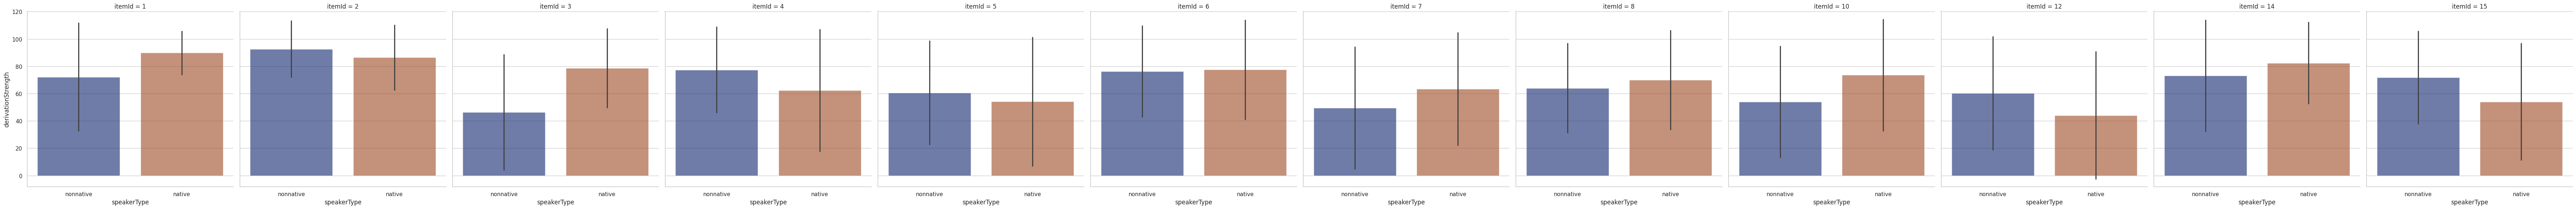

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

truly_difficult_items = [9, 11, 13, 16]
removed_faces = final_df[~final_df["itemId"].isin(truly_difficult_items)]

crit_only = removed_faces[removed_faces["itemType"] == "critical"]
# crit_only = ignore_13[ignore_13["itemType"] == "critical"]

sns.catplot(
    data=final_df, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemId",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6,
)

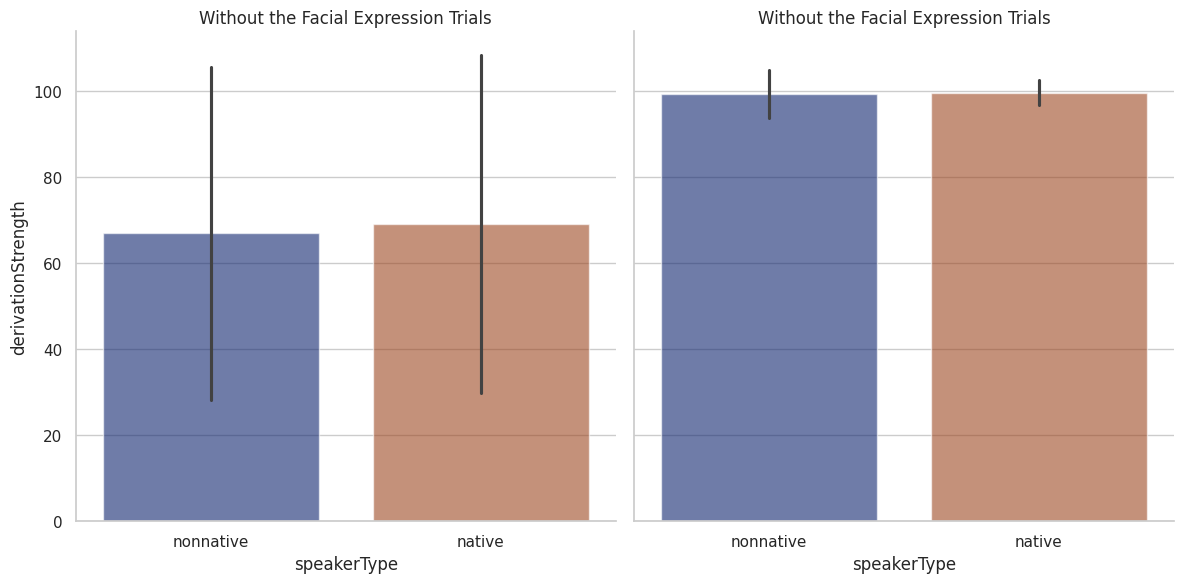

In [167]:
faceless = sns.catplot(
    data=removed_faces, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6,
).set(title='Without the Facial Expression Trials')

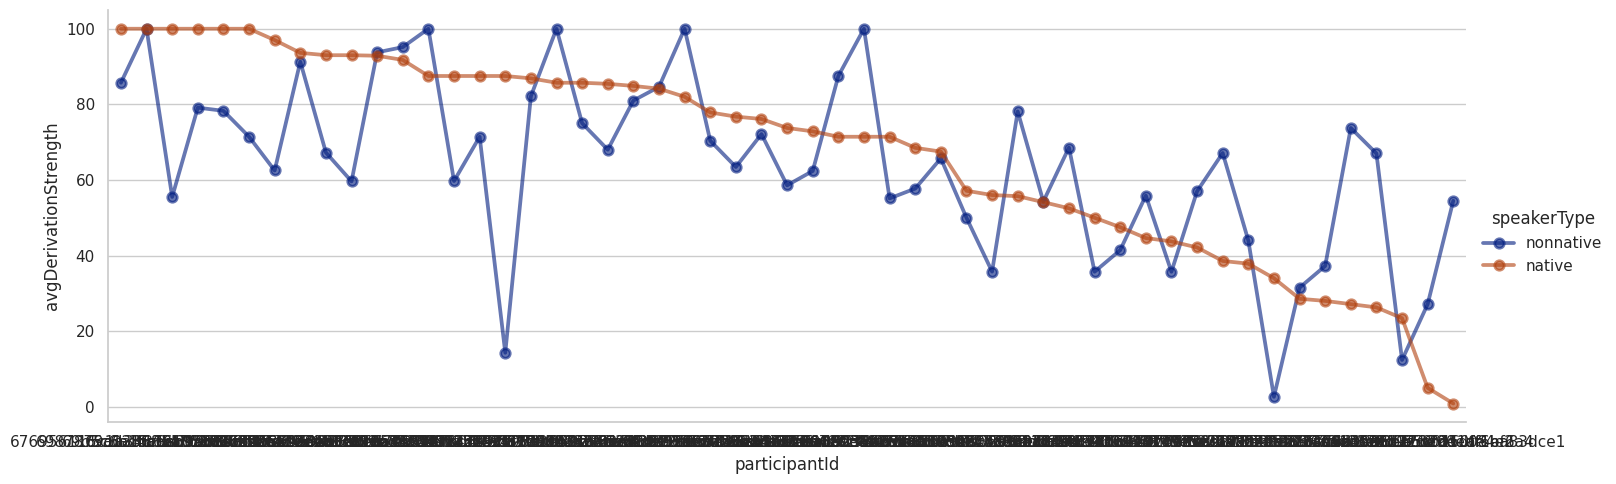

In [160]:
sorted_indiv_derivation_scores = crit_only.groupby(["participantId", "speakerType"])["derivationStrength"].mean().reset_index(
    name='avgDerivationStrength'
)

crits = sorted_indiv_derivation_scores[
    sorted_indiv_derivation_scores["speakerType"] == "native"
].sort_values(["avgDerivationStrength"], ascending=False).rename(columns={"avgDerivationStrength": "sortkey"})

sorted_indiv_derivation_scores = sorted_indiv_derivation_scores.merge(
    crits[["participantId", "sortkey"]], on="participantId"
).sort_values(["sortkey"], ascending=False)

# sorted_indiv_derivation_scores["range"] = range(1, len(sorted_indiv_derivation_scores) + 1)

sns.catplot(
    data=sorted_indiv_derivation_scores, kind="point",
    x="participantId", y="avgDerivationStrength",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6, height=5, aspect=3
)

# EXPLORATORY

In [168]:
final_df[final_df["participantId"] == "6987875a0a8fa6ed9ef00726"]

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,antonymRating,speakerType,speakerGender,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio
6,6987875a0a8fa6ed9ef00726,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,0.0,nonnative,female,1381,27970,18362,478,14284,834,1.767265
59,6987875a0a8fa6ed9ef00726,2,critical,good,excellent,bad,dramatic,technical,100.0,0.0,0.0,native,male,110,353973,2140,16094,283,134910,1.342306
112,6987875a0a8fa6ed9ef00726,3,critical,funny,hilarious,boring,resilient,erratic,100.0,0.0,0.0,native,female,1803,20399,10910,1310,4969,4922,1.192338
165,6987875a0a8fa6ed9ef00726,4,critical,cold,freezing,hot,fictional,communal,100.0,0.0,0.0,native,male,888,44649,6463,3226,722,54601,1.141147
218,6987875a0a8fa6ed9ef00726,5,critical,big,enormous,tiny,rural,creative,100.0,0.0,0.0,nonnative,male,162,227169,2007,17482,1320,29756,1.113758
271,6987875a0a8fa6ed9ef00726,6,critical,old,ancient,new,illegal,crazy,100.0,0.0,0.0,native,female,152,236577,1832,19818,88,435993,1.076913
324,6987875a0a8fa6ed9ef00726,7,critical,large,gigantic,little,scattered,incapable,100.0,0.0,0.0,nonnative,male,221,175611,7924,2287,257,149658,1.885286
377,6987875a0a8fa6ed9ef00726,8,critical,wet,drenched,dry,ephemeral,rudimentary,100.0,0.0,0.0,nonnative,female,2491,13963,20000,400,1570,23809,1.542919
430,6987875a0a8fa6ed9ef00726,9,critical,happy,ecstatic,sad,anecdotal,extravagant,100.0,0.0,0.0,native,female,748,51669,10656,1343,2164,16163,1.585154
483,6987875a0a8fa6ed9ef00726,10,critical,hot,scalding,cold,orchestral,gaunt,100.0,0.0,0.0,nonnative,male,722,54601,20000,400,888,44649,2.135141
